# **Preprocess**

## **Libraries**

In [35]:
pip install -U flwr

In [1]:
pip install -U "flwr[simulation]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import flwr as fl
import warnings

## **Desired Order for the Dataset**

In [3]:
desired_order = [
    "host",
    "IP",
    "IntervalDateTime",
    "start",
    "end",
    "duration_sec",
    "Total",
    "Method",
    "Response",
    "Response_bytes",
    "label"
]

## **Preprocessing Access-logs-2**

IP malevoli: 151.59.2.55, 151.59.5.47

In [4]:
df2 = pd.read_csv("access-logs-2.csv")
df2.columns = [
    "timestamp",
    "IntervalDateTime",
    "Total",
    "Response_bytes",
    "Method",
    "Response",
    "host",
    "IP"
]
df2.head()

,timestamp,IntervalDateTime,Total,Response_bytes,Method,Response,host,IP
0,1.775520e+09,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,1,127320,GET,20x,www.sardegnasolidale.it,185.112.144.11
1,1.775520e+09,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,1,15689,GET,20x,www.sardegnasolidale.it,54.38.147.133
2,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,31,POST,20x,www.sardegnasolidale.it,80.211.146.125
3,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,450,GET,20x,www.sardegnasolidale.it,207.180.11.166
4,1.775520e+09,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,1,15291,GET,20x,www.sardegnasolidale.it,198.244.242.173


In [5]:
# labeling the attack ips
malicious_ips = [
"151.59.2.55",
"151.59.5.47"
]

df2["label"] = df2["IP"].isin(malicious_ips).astype(int)
print(df2["label"].value_counts())
df2.head()

label
0    23247
1     5176
Name: count, dtype: int64


,timestamp,IntervalDateTime,Total,Response_bytes,Method,Response,host,IP,label
0,1.775520e+09,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,1,127320,GET,20x,www.sardegnasolidale.it,185.112.144.11,0
1,1.775520e+09,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,1,15689,GET,20x,www.sardegnasolidale.it,54.38.147.133,0
2,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,31,POST,20x,www.sardegnasolidale.it,80.211.146.125,0
3,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,450,GET,20x,www.sardegnasolidale.it,207.180.11.166,0
4,1.775520e+09,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,1,15291,GET,20x,www.sardegnasolidale.it,198.244.242.173,0


In [6]:
df2[["start", "end"]] = (
    df2["IntervalDateTime"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.split("-", expand=True)
)

df2["start"] = pd.to_datetime(df2["start"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
df2["end"]   = pd.to_datetime(df2["end"],   format="%d/%b/%Y:%H:%M:%S", errors="coerce")

df2["duration_sec"] = (df2["end"] - df2["start"]).dt.total_seconds()

df2 = df2.reindex(columns=desired_order)

df2.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Method,Response,Response_bytes,label
0,www.sardegnasolidale.it,185.112.144.11,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,2026-04-07 00:00:56,2026-04-07 00:00:56,0.0,1,GET,20x,127320,0
1,www.sardegnasolidale.it,54.38.147.133,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,2026-04-07 00:00:54,2026-04-07 00:00:54,0.0,1,GET,20x,15689,0
2,www.sardegnasolidale.it,80.211.146.125,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,POST,20x,31,0
3,www.sardegnasolidale.it,207.180.11.166,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,GET,20x,450,0
4,www.sardegnasolidale.it,198.244.242.173,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,2026-04-07 00:01:25,2026-04-07 00:01:25,0.0,1,GET,20x,15291,0


In [7]:
# IP -> frequency encoding
df2["IP_freq"] = df2["IP"].map(df2["IP"].value_counts())

# Method -> dummy encoding
df2 = pd.get_dummies(df2, columns=["Method"], drop_first=False, dtype=int)

df2.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Response,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,www.sardegnasolidale.it,185.112.144.11,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,2026-04-07 00:00:56,2026-04-07 00:00:56,0.0,1,20x,127320,0,1,1,0,0
1,www.sardegnasolidale.it,54.38.147.133,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,2026-04-07 00:00:54,2026-04-07 00:00:54,0.0,1,20x,15689,0,4,1,0,0
2,www.sardegnasolidale.it,80.211.146.125,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,20x,31,0,3495,0,0,1
3,www.sardegnasolidale.it,207.180.11.166,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,20x,450,0,1,1,0,0
4,www.sardegnasolidale.it,198.244.242.173,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,2026-04-07 00:01:25,2026-04-07 00:01:25,0.0,1,20x,15291,0,1,1,0,0


In [8]:
# Drop unnecessary columns
df2 = df2.drop(["IntervalDateTime", "host", "start", "end", "IP", "Response"], axis=1)

df2.head()

,duration_sec,Total,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,0.0,1,127320,0,1,1,0,0
1,0.0,1,15689,0,4,1,0,0
2,0.0,1,31,0,3495,0,0,1
3,0.0,1,450,0,1,1,0,0
4,0.0,1,15291,0,1,1,0,0


In [9]:
# Check NA values
df2.isna().sum()

,0
duration_sec,0
Total,0
Response_bytes,0
label,0
IP_freq,0
Method_GET,0
Method_OTHER,0
Method_POST,0


In [10]:
# Check negative values (to avoid making NA in log trasnform)
(df2.select_dtypes(include="number") <= -1).sum()

# Drop negative values (before log transform)
df2 = df2[(df2 > -1).all(axis=1)]

In [11]:
# Log-transform skewed features
df2["duration_sec"] = np.log1p(df2["duration_sec"])
df2["Response_bytes"] = np.log1p(df2["Response_bytes"])
df2["IP_freq"] = np.log1p(df2["IP_freq"])
df2["Total"] = np.log1p(df2["Total"])

# Scale selected features
features_to_scale = ["duration_sec", "Response_bytes", "IP_freq", "Total"]

scaler = MinMaxScaler()
df2[features_to_scale] = scaler.fit_transform(df2[features_to_scale])
df2 = df2.reindex(columns=["duration_sec", "Total", "Response_bytes", "IP_freq", "Method_GET", "Method_OTHER", "Method_POST", "label"])
df2.head()

,duration_sec,Total,Response_bytes,IP_freq,Method_GET,Method_OTHER,Method_POST,label
0,0.0,0.0,0.668448,0.000000,1,0,0,0
1,0.0,0.0,0.549385,0.118007,1,0,0,0
2,0.0,0.0,0.197088,0.961558,0,0,1,0
3,0.0,0.0,0.347544,0.000000,1,0,0,0
4,0.0,0.0,0.547924,0.000000,1,0,0,0


## **Preprocessing Access-logs-3**

IP malevoli: 151.59.134.10, 151.59.134.15, 151.59.128.186, 151.59.132.209

In [12]:
df3 = pd.read_csv("access-logs-3.csv")
df3.columns = [
    "timestamp",
    "Response",
    "IP",
    "IntervalDateTime",
    "Total",
    "Response_bytes",
    "Method",
    "host"
]
df3.head()

,timestamp,Response,IP,IntervalDateTime,Total,Response_bytes,Method,host
0,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,1,31,POST,www.sardegnasolidale.it
1,1.775750e+09,20x,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,1,589,GET,www.sardegnasolidale.it
2,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,31,POST,www.sardegnasolidale.it
3,1.775750e+09,20x,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,497,GET,www.sardegnasolidale.it
4,1.775750e+09,20x,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,1,524,GET,www.sardegnasolidale.it


In [13]:
malicious_ips = [
    "151.59.134.10",
    "151.59.134.15",
    "151.59.128.186",
    "151.59.132.209"
]

df3["label"] = df3["IP"].isin(malicious_ips).astype(int)
print(df3["label"].value_counts())
df3.head()

label
0    32539
1    23941
Name: count, dtype: int64


,timestamp,Response,IP,IntervalDateTime,Total,Response_bytes,Method,host,label
0,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,1,31,POST,www.sardegnasolidale.it,0
1,1.775750e+09,20x,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,1,589,GET,www.sardegnasolidale.it,0
2,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,31,POST,www.sardegnasolidale.it,0
3,1.775750e+09,20x,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,497,GET,www.sardegnasolidale.it,0
4,1.775750e+09,20x,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,1,524,GET,www.sardegnasolidale.it,0


In [14]:
df3[["start", "end"]] = (
    df3["IntervalDateTime"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.split("-", expand=True)
)

df3["start"] = pd.to_datetime(df3["start"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
df3["end"]   = pd.to_datetime(df3["end"],   format="%d/%b/%Y:%H:%M:%S", errors="coerce")

df3["duration_sec"] = (df3["end"] - df3["start"]).dt.total_seconds()

df3 = df3.reindex(columns=desired_order)

df3.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Method,Response,Response_bytes,label
0,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,2026-04-09 15:47:05,2026-04-09 15:47:05,0.0,1,POST,20x,31,0
1,www.sardegnasolidale.it,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,2026-04-09 15:47:23,2026-04-09 15:47:23,0.0,1,GET,20x,589,0
2,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,POST,20x,31,0
3,www.sardegnasolidale.it,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,GET,20x,497,0
4,www.sardegnasolidale.it,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,2026-04-09 15:49:22,2026-04-09 15:49:22,0.0,1,GET,20x,524,0


In [15]:
# IP -> frequency encoding
df3["IP_freq"] = df3["IP"].map(df3["IP"].value_counts())

# Method -> dummy encoding
df3 = pd.get_dummies(df3, columns=["Method"], drop_first=False, dtype=int)

df3.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Response,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,2026-04-09 15:47:05,2026-04-09 15:47:05,0.0,1,20x,31,0,5313,0,0,1
1,www.sardegnasolidale.it,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,2026-04-09 15:47:23,2026-04-09 15:47:23,0.0,1,20x,589,0,1,1,0,0
2,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,20x,31,0,5313,0,0,1
3,www.sardegnasolidale.it,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,20x,497,0,1,1,0,0
4,www.sardegnasolidale.it,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,2026-04-09 15:49:22,2026-04-09 15:49:22,0.0,1,20x,524,0,2,1,0,0


In [16]:
# Drop unnecessary columns
df3 = df3.drop(["IntervalDateTime", "host", "start", "end", "IP", "Response"], axis=1)

df3.head()

,duration_sec,Total,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,0.0,1,31,0,5313,0,0,1
1,0.0,1,589,0,1,1,0,0
2,0.0,1,31,0,5313,0,0,1
3,0.0,1,497,0,1,1,0,0
4,0.0,1,524,0,2,1,0,0


In [17]:
# Check NA values
df3.isna().sum()

,0
duration_sec,0
Total,0
Response_bytes,0
label,0
IP_freq,0
Method_GET,0
Method_OTHER,0
Method_POST,0


In [18]:
# Check negative values (to avoid making NA in log trasnform)
(df3.select_dtypes(include="number") <= -1).sum()

# Drop negative values (before log transform)
df3 = df3[(df3 > -1).all(axis=1)]

In [19]:
# Log-transform skewed features
df3["duration_sec"] = np.log1p(df3["duration_sec"])
df3["Response_bytes"] = np.log1p(df3["Response_bytes"])
df3["IP_freq"] = np.log1p(df3["IP_freq"])
df3["Total"] = np.log1p(df3["Total"])

# Scale selected features
features_to_scale = ["duration_sec", "Response_bytes", "IP_freq", "Total"]

scaler = MinMaxScaler()
df3[features_to_scale] = scaler.fit_transform(df3[features_to_scale])
df3 = df3.reindex(columns=["duration_sec", "Total", "Response_bytes", "IP_freq", "Method_GET", "Method_OTHER", "Method_POST", "label"])
df3.head()

,duration_sec,Total,Response_bytes,IP_freq,Method_GET,Method_OTHER,Method_POST,label
0,0.0,0.0,0.197165,0.942223,0,0,1,0
1,0.0,0.0,0.362963,0.000000,1,0,0,0
2,0.0,0.0,0.197165,0.942223,0,0,1,0
3,0.0,0.0,0.353319,0.000000,1,0,0,0
4,0.0,0.0,0.356323,0.048452,1,0,0,0


## **Preprocessing Access-logs-4**

IP malevolo: 77.89.34.239

In [20]:
df4 = pd.read_csv("access-logs-4.csv")
df4.columns = [
    "timestamp",
    "Response_bytes",
    "Response",
    "Method",
    "host",
    "IP",
    "IntervalDateTime",
    "Total"
]
df4.head()

,timestamp,Response_bytes,Response,Method,host,IP,IntervalDateTime,Total
0,1.776094e+09,2797564,20x,GET,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,75
1,1.776094e+09,29929,20x,GET,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,1
2,1.776094e+09,557,20x,GET,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,1
3,1.776094e+09,664,20x,GET,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,1
4,1.776094e+09,13595,20x,POST,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,5


In [21]:
# labeling the attack ips
malicious_ips = [
"77.89.34.239",
]

df4["label"] = df4["IP"].isin(malicious_ips).astype(int)
print(df4["label"].value_counts())
df4.head()

label
1    86513
0    82791
Name: count, dtype: int64


,timestamp,Response_bytes,Response,Method,host,IP,IntervalDateTime,Total,label
0,1.776094e+09,2797564,20x,GET,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,75,0
1,1.776094e+09,29929,20x,GET,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,1,0
2,1.776094e+09,557,20x,GET,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,1,0
3,1.776094e+09,664,20x,GET,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,1,0
4,1.776094e+09,13595,20x,POST,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,5,1


In [22]:
df4[["start", "end"]] = (
    df4["IntervalDateTime"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.split("-", expand=True)
)

df4["start"] = pd.to_datetime(df4["start"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
df4["end"]   = pd.to_datetime(df4["end"],   format="%d/%b/%Y:%H:%M:%S", errors="coerce")

df4["duration_sec"] = (df4["end"] - df4["start"]).dt.total_seconds()

df4 = df4.reindex(columns=desired_order)

df4.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Method,Response,Response_bytes,label
0,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,2026-04-13 15:32:01,2026-04-13 15:32:03,2.0,75,GET,20x,2797564,0
1,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,2026-04-13 15:31:56,2026-04-13 15:31:56,0.0,1,GET,20x,29929,0
2,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,2026-04-13 15:32:00,2026-04-13 15:32:00,0.0,1,GET,20x,557,0
3,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,2026-04-13 15:32:02,2026-04-13 15:32:02,0.0,1,GET,20x,664,0
4,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,2026-04-13 15:32:36,2026-04-13 15:32:40,4.0,5,POST,20x,13595,1


In [23]:
# IP -> frequency encoding
df4["IP_freq"] = df4["IP"].map(df4["IP"].value_counts())

# Method -> dummy encoding
df4 = pd.get_dummies(df4, columns=["Method"], drop_first=False, dtype=int)

df4.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Response,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,2026-04-13 15:32:01,2026-04-13 15:32:03,2.0,75,20x,2797564,0,2,1,0,0
1,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,2026-04-13 15:31:56,2026-04-13 15:31:56,0.0,1,20x,29929,0,1,1,0,0
2,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,2026-04-13 15:32:00,2026-04-13 15:32:00,0.0,1,20x,557,0,1,1,0,0
3,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,2026-04-13 15:32:02,2026-04-13 15:32:02,0.0,1,20x,664,0,3,1,0,0
4,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,2026-04-13 15:32:36,2026-04-13 15:32:40,4.0,5,20x,13595,1,86513,0,0,1


In [24]:
# Drop unnecessary columns
df4 = df4.drop(["IntervalDateTime", "host", "start", "end", "IP", "Response"], axis=1)

df4.head()

,duration_sec,Total,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,2.0,75,2797564,0,2,1,0,0
1,0.0,1,29929,0,1,1,0,0
2,0.0,1,557,0,1,1,0,0
3,0.0,1,664,0,3,1,0,0
4,4.0,5,13595,1,86513,0,0,1


In [25]:
# Check NA values
df4.isna().sum()

,0
duration_sec,0
Total,0
Response_bytes,0
label,0
IP_freq,0
Method_GET,0
Method_OTHER,0
Method_POST,0


In [26]:
# Check negative values (to avoid making NA in log trasnform)
(df4.select_dtypes(include="number") <= -1).sum()

# Drop negative values (before log transform)
df4 = df4[(df4 > -1).all(axis=1)]

In [27]:
# Log-transform skewed features
df4["duration_sec"] = np.log1p(df4["duration_sec"])
df4["Response_bytes"] = np.log1p(df4["Response_bytes"])
df4["IP_freq"] = np.log1p(df4["IP_freq"])
df4["Total"] = np.log1p(df4["Total"])

# Scale selected features
features_to_scale = ["duration_sec", "Response_bytes", "IP_freq", "Total"]

scaler = MinMaxScaler()
df4[features_to_scale] = scaler.fit_transform(df4[features_to_scale])
df4 = df4.reindex(columns=["duration_sec", "Total", "Response_bytes", "IP_freq", "Method_GET", "Method_OTHER", "Method_POST", "label"])
df4.head()

,duration_sec,Total,Response_bytes,IP_freq,Method_GET,Method_OTHER,Method_POST,label
0,0.250000,0.746727,0.862626,0.037983,1,0,0,0
1,0.000000,0.000000,0.598935,0.000000,1,0,0,0
2,0.000000,0.000000,0.367519,0.000000,1,0,0,0
3,0.000000,0.000000,0.377714,0.064932,1,0,0,0
4,0.366243,0.225524,0.553080,1.000000,0,0,1,1


# **Training**

## **Global Variables**

In [28]:
IMPORTANT_FEAT = ["IP_freq", "Total", "duration_sec", "Response_bytes"]
LABEL          = "label"

# Iperparametri autoencoder
INPUT_DIM  = len(IMPORTANT_FEAT)   # 4
EPOCHS     = 10     # epoche per round per client (tieni basso in FL)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2    # percentuale di X_normal usata per validation

# Iperparametri Federated Learning
NUM_ROUNDS       = 2   # round di aggregazione
FRACTION         = 1.0  # percentuale di client usati per il training e validation
MIN_CLIENTS      = 3    # minimo numero di client che devono partecipare al training e al validation

## **AutoEncoder construction**

In [29]:
def build_autoencoder() -> Model:
    """
    Architettura:
        Encoder: input_dim → 8 → 4 → 2  (collo di bottiglia)
        Decoder: 2 → 4 → 8 → input_dim
    """

    # Encoder
    inputs  = tf.keras.Input(shape=(INPUT_DIM,))
    encoded = layers.Dense(8, activation='relu')(inputs)
    encoded = layers.Dense(4, activation='relu')(encoded)
    latent  = layers.Dense(2, activation='relu')(encoded)  # collo di bottiglia

    # Decoder
    decoded = layers.Dense(4, activation='relu')(latent)
    decoded = layers.Dense(8, activation='relu')(decoded)
    outputs = layers.Dense(INPUT_DIM, activation='linear')(decoded)

    autoencoder = Model(inputs, outputs)
    autoencoder.compile(optimizer="adam", loss='mse')
    #autoencoder.summary()
    return autoencoder

In [37]:
def load_client_data(cid: int):
    """
    Carica il CSV del client, separa traffico normale e anomalo,
    e restituisce X_train, X_val, X_anomaly come numpy array.
    """
    if cid == 0:
      X = df2[IMPORTANT_FEAT].values
      Y = df2[LABEL].values
      dataset = "access-logs-2"
    elif cid == 1:
      X = df3[IMPORTANT_FEAT].values
      Y = df3[LABEL].values
      dataset = "access-logs-3"
    else:
      X = df4[IMPORTANT_FEAT].values
      Y = df4[LABEL].values
      dataset = "access-logs-4"

    X_normal  = X[Y == 0]           # solo traffico normale
    X_anomaly = X[Y == 1]           # solo attacchi — mai usati in training

    X_train, X_val = train_test_split(X_normal, test_size=VAL_SPLIT, random_state=42)

    print(f"  [Dataset: {dataset}]")
    print(f"  Totale righe  : {len(X)}")
    print(f"  Normale       : {len(X_normal)}")
    print(f"  Anomalo       : {len(X_anomaly)}")
    print(f"  X_train shape : {X_train.shape}")
    print(f"  X_val shape   : {X_val.shape}")

    return X_train, X_val, X_anomaly, Y

## **Flower Client**

In [ ]:
class AutoencoderClient(fl.client.NumPyClient):
    """
    Client Flower che addestra un autoencoder localmente
    sul proprio traffico normale e condivide i pesi con il server.
    """

    def __init__(self, client_id: int):
        self.client_id = client_id
        print(f"\n[Client {client_id}] Caricamento dati...")
        self.X_train, self.X_val, self.X_anomaly, self.Y_all = load_client_data(self.client_id)

        # Costruisce il modello locale — pesi casuali, stessa architettura
        self.model = build_autoencoder()

    # ────────── Restituisce i pesi attuali al server ──────────
    def get_parameters(self, config):
        return self.model.get_weights()

    # ── Riceve pesi globali, addestra localmente, rimanda i pesi ──
    def fit(self, parameters, config):
        # 1. Carica i pesi globali ricevuti dal server
        self.model.set_weights(parameters)

        # 2. Addestra SOLO sul traffico normale locale
        self.model.fit(
            self.X_train, self.X_train,     # input = output (ricostruzione)
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(self.X_val, self.X_val),
            verbose=0,                       # silenzia l'output per chiarezza
        )

        # 3. Restituisce i pesi aggiornati + numero di campioni usati
        #    (il server usa num_examples per pesare l'aggregazione FedAvg)
        return self.get_parameters(config), len(self.X_train), {}

    # ── Valuta il modello globale sul proprio dataset locale ───────
    def evaluate(self, parameters, config):
        self.model.set_weights(parameters)

        # Loss sul traffico normale (X_val)
        val_reconstructed = self.model.predict(self.X_val, verbose=0)
        val_mse = np.mean(np.power(self.X_val - val_reconstructed, 2), axis=1)
        loss = float(np.mean(val_mse))

        # Calcola la soglia locale
        threshold = np.mean(val_mse) + 2 * np.std(val_mse)

        # Valutazione su X_test = X_val + X_anomaly
        X_test = np.concatenate([self.X_val, self.X_anomaly])
        Y_test = np.concatenate([np.zeros(len(self.X_val)), np.ones(len(self.X_anomaly))])

        test_reconstructed = self.model.predict(X_test, verbose=0)
        test_mse = np.mean(np.power(X_test - test_reconstructed, 2), axis=1)
        y_pred   = (test_mse > threshold).astype(int)

        acc = float(accuracy_score(Y_test, y_pred))
        print(f"\n[Client {self.client_id}] loss={loss:.4f} | accuracy={acc:.4f} | soglia={threshold:.4f}")

        return loss, len(X_test), {"accuracy": acc}

In [31]:
def client_fn(cid: int) -> AutoencoderClient:
    """
    Flower passa l'ID del client (0, 1, 2).
    Ritorniamo l'istanza del client con il dataset corrispondente.
    """
    return AutoencoderClient(client_id=cid)

## **Aggregation Callback**

In [32]:
def evaluate_aggregated(server_round: int, parameters: fl.common.NDArrays, config: dict,):
    """
    Chiamata dal server dopo ogni aggregazione FedAvg.
    Valuta il modello globale su tutti e 3 i dataset combinati.
    """
    print(f"\n{'='*50}")
    print(f"  ROUND {server_round} — Valutazione modello globale")
    print(f"{'='*50}")

    # Carica il modello globale con i pesi aggregati
    global_model = build_autoencoder()
    global_model.set_weights(parameters)

    all_mse    = []
    all_Y_test = []

    for i in range(MIN_CLIENTS):
        if i == 0:
          X = df2[IMPORTANT_FEAT].values
          Y = df2[LABEL].values
        elif i == 1:
          X = df3[IMPORTANT_FEAT].values
          Y = df3[LABEL].values
        else:
          X = df4[IMPORTANT_FEAT].values
          Y = df4[LABEL].values

        X_normal  = X[Y == 0]
        X_anomaly = X[Y == 1]
        _, X_val  = train_test_split(X_normal, test_size=VAL_SPLIT, random_state=42)

        X_test = np.concatenate([X_val, X_anomaly])
        Y_test = np.concatenate([np.zeros(len(X_val)), np.ones(len(X_anomaly))])

        reconstructed = global_model.predict(X_test, verbose=0)
        mse = np.mean(np.power(X_test - reconstructed, 2), axis=1)

        all_mse.append(mse)
        all_Y_test.append(Y_test)

    # Concatena tutto
    all_mse    = np.concatenate(all_mse)
    all_Y_test = np.concatenate(all_Y_test)

    # Soglia globale calcolata sul normale aggregato
    normal_mse = all_mse[all_Y_test == 0]
    threshold  = np.mean(normal_mse) + 2 * np.std(normal_mse)
    y_pred     = (all_mse > threshold).astype(int)

    acc  = accuracy_score(all_Y_test, y_pred)
    prec = precision_score(all_Y_test, y_pred, zero_division=0)
    rec  = recall_score(all_Y_test, y_pred, zero_division=0)
    f1   = f1_score(all_Y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(all_Y_test, all_mse)

    print(f"  Soglia globale : {threshold:.4f}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Precision      : {prec:.4f}")
    print(f"  Recall         : {rec:.4f}")
    print(f"  F1 Score       : {f1:.4f}")
    print(f"  AUC-ROC        : {auc:.4f}")

    return float(np.mean(normal_mse)), {"accuracy": acc, "f1": f1, "auc": auc}

## **Main**

In [33]:
class CustomFedAvg(fl.server.strategy.FedAvg):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.final_parameters = None

    def aggregate_fit(self, server_round: int, results, failures):

        # Chiama il metodo della classe base per fare la classica aggregazione FedAvg
        aggregated_parameters = super().aggregate_fit(server_round, results, failures)

        # Salva i parametri aggregati di questo round (l'ultimo round sovrascriverà i precedenti)
        if aggregated_parameters is not None:
            self.final_parameters, _ = aggregated_parameters

        return aggregated_parameters

In [38]:
if __name__ == "__main__":

    print("\n" + "="*50)
    print("  FEDERATED LEARNING — Autoencoder Anomaly Detection")
    print("  3 client | FedAvg | {} round".format(NUM_ROUNDS))
    print("="*50)

    base_model = build_autoencoder()
    initial_weights = fl.common.ndarrays_to_parameters(base_model.get_weights())

    # Strategia FedAvg con callback di valutazione globale
    strategy = CustomFedAvg(
        fraction_fit=FRACTION,
        fraction_evaluate=FRACTION,
        min_fit_clients=MIN_CLIENTS,
        min_evaluate_clients=MIN_CLIENTS,
        min_available_clients=MIN_CLIENTS,
        evaluate_fn=evaluate_aggregated,    # valutazione globale ad ogni round
        initial_parameters=initial_weights
    )

    # Avvia la simulazione — tutti i client girano sulla stessa macchina
    history = fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=MIN_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
        strategy=strategy,
        client_resources={"num_cpus": 1},   # risorse per client simulato
    )

    # ── Salvataggio del modello globale finale ────────────────────
    print("\n[Server] Salvataggio modello globale...")

    # Recupera i pesi dell'ultimo round dalla strategia personalizzata
    if strategy.final_parameters is not None:
        # Converte i parametri di Flower in una lista di array NumPy
        weights = fl.common.parameters_to_ndarrays(strategy.final_parameters)

        # Costruisci il tuo autoencoder
        global_model = build_autoencoder()

        # Imposta i pesi nel modello TensorFlow/Keras o PyTorch
        global_model.set_weights(weights)  # Se usi Keras/TensorFlow
        global_model.save("FL_AutoEncoder.keras")
        print("[Server] Modello salvato in: federated_autoencoder_global.keras")
    else:
        print("Impossibile recuperare i parametri finali.")

    print("\n[Fine simulazione]")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=2, no round_timeout



  FEDERATED LEARNING — Autoencoder Anomaly Detection
  3 client | FedAvg | 2 round


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-07-07 12:33:07,596	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'accelerator_type:T4': 1.0, 'object_store_memory': 3960739430.0, 'CPU': 2.0, 'node:172.28.0.12': 1.0, 'GPU': 1.0, 'node:__internal_head__': 1.0, 'memory': 9241725338.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evalu


  ROUND 0 — Valutazione modello globale


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      initial parameters (loss, other metrics): 0.13347525987552325, {'accuracy': 0.9645542952018193, 'f1': 0.977766692483733, 'auc': np.float64(0.9899010078341586)}
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

(ClientAppActor pid=3317) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: int">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=3317) 
(ClientAppActor pid=3317)             This is a deprecated feature. It will be removed
(ClientAppActor pid=3317)             entirely in future versions of Flower.
(ClientAppActor pid=3317)         
(ClientAppActor pid=3317) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=3317) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.


(ClientAppActor pid=3318) 


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 2 round(s) in 334.25s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.011424301896099488
INFO :      		round 2: 0.0019884379519185553
INFO :      	History (loss, centralized):
INFO :      		round 0: 0.13347525987552325
INFO :      		round 1: 0.011055944292302458
INFO :      		round 2: 0.0018008242659884022
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.9645542952018193),
INFO :      	              (1, 0.9708467623791386),
INFO :      	              (2, 0.9804249856989382)],
INFO :      	 'auc': [(0, np.float64(0.9899010078341586)),
INFO :      	         (1, np.float64(0.9840056335103332)),
INFO :      	         (2, np.float64(0.9946784375771617))],
INFO :      	 'f1': [(0, 0.977766692483733),
INFO :      	        (1, 0.9818576483101434),
INFO :      	        (2, 0.9878251965497492)]}
INFO :      



[Server] Salvataggio modello globale...
(ClientAppActor pid=3317) 
(ClientAppActor pid=3317) [Client 1] loss=0.0020 | accuracy=0.9827 | soglia=0.0165 [repeated 2x across cluster]
[Server] Modello salvato in: federated_autoencoder_global.keras

[Fine simulazione]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **Chart**

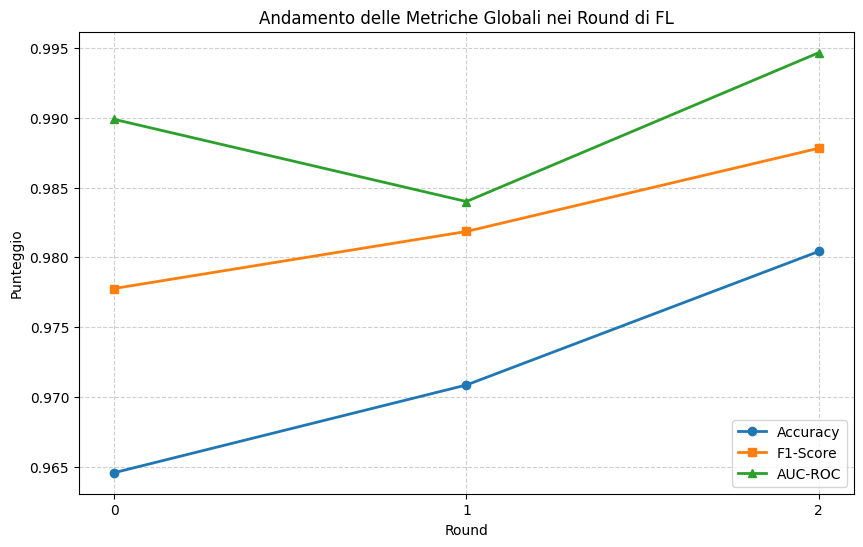

In [45]:
import matplotlib.pyplot as plt

# 1. Estrai i round e i valori dall'oggetto history di Flower
# Nota: 'history.metrics_centralized' contiene le metriche restituite da evaluate_aggregated
rounds = [r for r, _ in history.metrics_centralized["accuracy"]]

accuracy = [val for _, val in history.metrics_centralized["accuracy"]]
f1_score = [val for _, val in history.metrics_centralized["f1"]]
auc_roc = [val for _, val in history.metrics_centralized["auc"]]

# 2. Crea il grafico
plt.figure(figsize=(10, 6))

plt.plot(rounds, accuracy, label='Accuracy', marker='o', linewidth=2)
plt.plot(rounds, f1_score, label='F1-Score', marker='s', linewidth=2)
plt.plot(rounds, auc_roc, label='AUC-ROC', marker='^', linewidth=2)

plt.title('Andamento delle Metriche Globali nei Round di FL')
plt.xlabel('Round')
plt.ylabel('Punteggio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.xticks(rounds)

# Mostra il grafico
plt.show()